In [129]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import yfinance as yf
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [130]:
# 1.1 Загрузка данных
tickers = {"NVDA": "NVIDIA Corporation", "DPZ": "Domino's Pizza Inc."}
start_date = "2017-01-01"
end_date = datetime.now().strftime("%Y-%m-%d")

data = {}
for ticker, name in tickers.items():
    print(f"Загрузка данных для {name} ({ticker})...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=False, multi_level_index=False)
    df.index = pd.to_datetime(df.index)
    close_col = next((col for col in df.columns if "close" in str(col).lower()), None)
    if close_col is None:
        raise ValueError(f"Колонка с ценой закрытия не найдена для {ticker}.")
    df = df.dropna(subset=[close_col])
    df = df.rename(columns={close_col: "Close"})
    data[ticker] = df
    print(f"✓ Загружено {len(df)} записей для {ticker}")
    print(f" Период: {df.index.min().date()} — {df.index.max().date()}\n")

Загрузка данных для NVIDIA Corporation (NVDA)...
✓ Загружено 2364 записей для NVDA
 Период: 2017-01-03 — 2026-05-29

Загрузка данных для Domino's Pizza Inc. (DPZ)...
✓ Загружено 2364 записей для DPZ
 Период: 2017-01-03 — 2026-05-29



In [131]:
# Создаем датасеты с ценами закрытия
ts_datasets = {}
for ticker, df in data.items():
    ts = df['Close'].copy()
    ts.name = f'{ticker}_Close'
    ts_datasets[ticker] = ts
    print(f"{ticker}: {len(ts)} наблюдений, диапазон цен: ${ts.min():.2f} — ${ts.max():.2f}")

NVDA: 2364 наблюдений, диапазон цен: $2.35 — $235.74
DPZ: 2364 наблюдений, диапазон цен: $142.60 — $531.43


In [132]:
def calculate_basic_stats(ts, ticker):
    stats = {
        'Наблюдений': len(ts),
        'Период': f"{ts.index.min().date()} — {ts.index.max().date()}",
        'Среднее': f"${ts.mean():.2f}",
        'Медиана': f"${ts.median():.2f}",
        'Стд. отклонение': f"${ts.std():.2f}",
        'Минимум': f"${ts.min():.2f}",
        'Максимум': f"${ts.max():.2f}",
        'Размах': f"${ts.max() - ts.min():.2f}",
        'Коэф. вариации': f"{(ts.std() / ts.mean() * 100):.2f}%",
        'Асимметрия': f"{ts.skew():.3f}",
        'Эксцесс': f"{ts.kurtosis():.3f}",
    }
    return pd.Series(stats, name=ticker)

stats_report = pd.DataFrame([
    calculate_basic_stats(ts_datasets[ticker], ticker)
    for ticker in ts_datasets.keys()
]).T

print("📊 БАЗОВЫЕ СТАТИСТИКИ ВРЕМЕННЫХ РЯДОВ")
print("=" * 60)
print(stats_report.to_string())

📊 БАЗОВЫЕ СТАТИСТИКИ ВРЕМЕННЫХ РЯДОВ
                                    NVDA                      DPZ
Наблюдений                          2364                     2364
Период           2017-01-03 — 2026-05-29  2017-01-03 — 2026-05-29
Среднее                           $46.48                  $334.71
Медиана                           $15.66                  $351.36
Стд. отклонение                   $60.09                   $97.37
Минимум                            $2.35                  $142.60
Максимум                         $235.74                  $531.43
Размах                           $233.39                  $388.83
Коэф. вариации                   129.28%                   29.09%
Асимметрия                         1.392                   -0.179
Эксцесс                            0.503                   -1.018


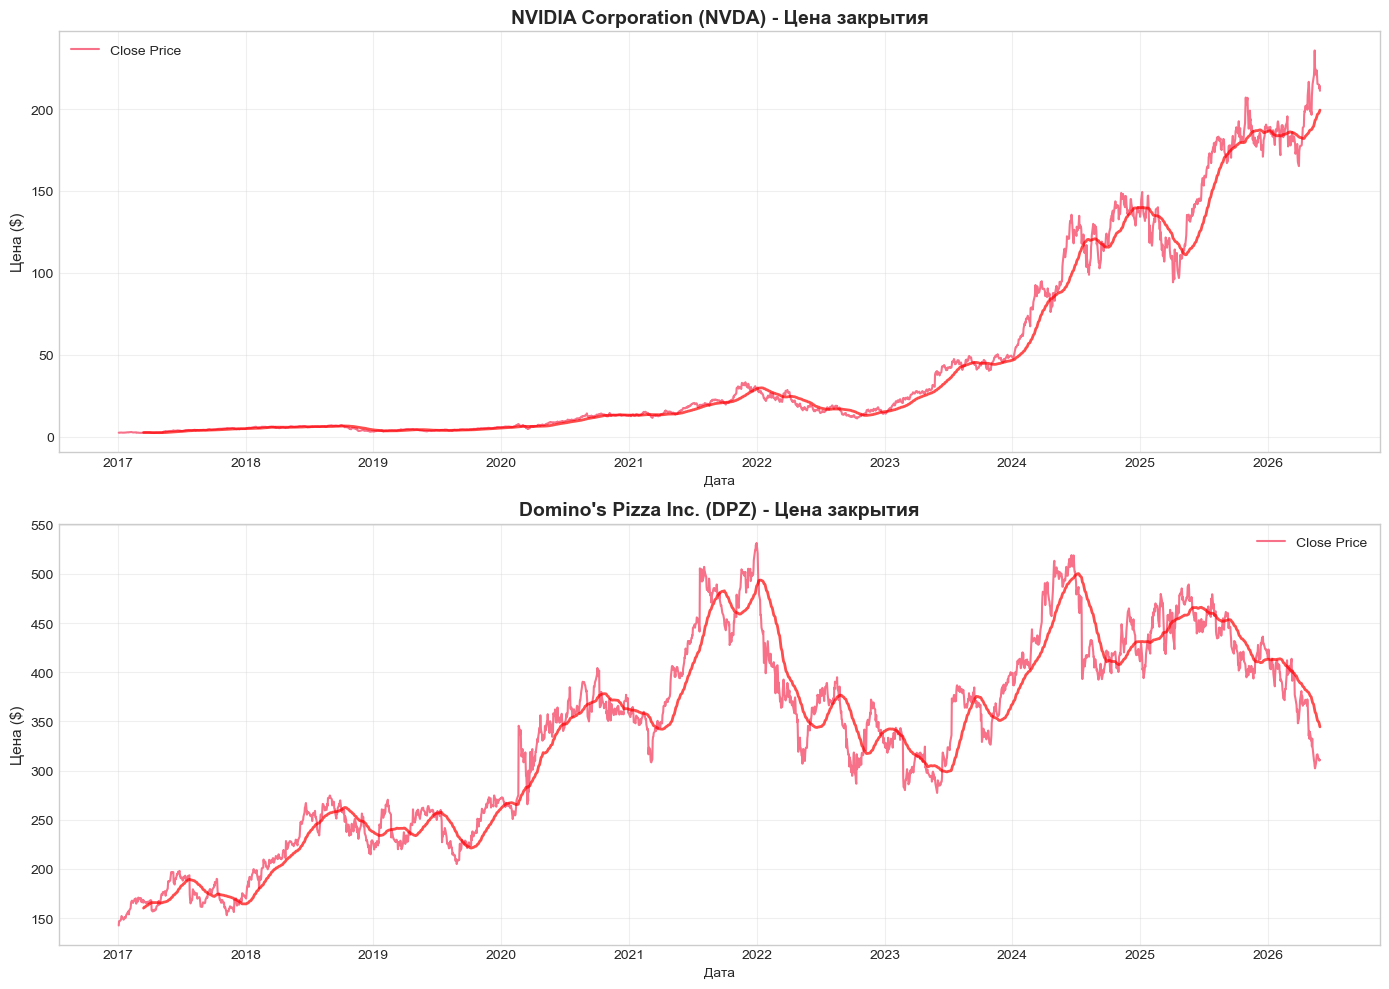

In [133]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
for idx, (ticker, ts) in enumerate(ts_datasets.items()):
    ax = axes[idx]
    ax.plot(ts.index, ts.values, linewidth=1.5, label='Close Price')
    ax.set_title(f'{tickers[ticker]} ({ticker}) - Цена закрытия', fontsize=14, fontweight='bold')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Цена ($)', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ts_ma = ts.rolling(window=50).mean()
    ax.plot(ts_ma.index, ts_ma.values, linewidth=2, label='MA(50)', color='red', alpha=0.7)
plt.tight_layout()
plt.show()

In [134]:
def test_stationarity(timeseries, name):
    print(f"🔍 Тест Дики-Фуллера для {name}:")
    print("-" * 50)
    result = adfuller(timeseries.dropna(), autolag='AIC')
    output = pd.Series(result[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in result[4].items():
        output[f'Critical Value ({key})'] = value
    print(output)
    if result[1] <= 0.05:
        print(f"✅ Ряд {name} СТАЦИОНАРЕН (p-value = {result[1]:.4f} < 0.05)")
        return True, result
    else:
        print(f"✗ Ряд {name} НЕ СТАЦИОНАРЕН (p-value = {result[1]:.4f} >= 0.05)")
        return False, result

stationarity_results = {}
for ticker, ts in ts_datasets.items():
    is_stat, result = test_stationarity(ts, ticker)
    stationarity_results[ticker] = {'original': is_stat, 'adf_result': result}

🔍 Тест Дики-Фуллера для NVDA:
--------------------------------------------------
Test Statistic                    1.843318
p-value                           0.998431
#Lags Used                       27.000000
Number of Observations Used    2336.000000
Critical Value (1%)              -3.433152
Critical Value (5%)              -2.862778
Critical Value (10%)             -2.567429
dtype: float64
✗ Ряд NVDA НЕ СТАЦИОНАРЕН (p-value = 0.9984 >= 0.05)
🔍 Тест Дики-Фуллера для DPZ:
--------------------------------------------------
Test Statistic                   -2.119563
p-value                           0.236721
#Lags Used                        4.000000
Number of Observations Used    2359.000000
Critical Value (1%)              -3.433125
Critical Value (5%)              -2.862766
Critical Value (10%)             -2.567423
dtype: float64
✗ Ряд DPZ НЕ СТАЦИОНАРЕН (p-value = 0.2367 >= 0.05)


In [135]:
def make_stationary(ts, ticker, max_diff_order=2):
    print(f"\U0001f504 Преобразование {ticker} к стационарному виду:")
    print("=" * 60)

    original_ts = ts.copy()
    res_orig = adfuller(original_ts.dropna(), autolag='AIC')
    if res_orig[1] <= 0.05:
        print(f"✓ Ряд уже стационарен!")
        return original_ts, 0, "original"

    if (original_ts > 0).all():
        log_ts = np.log(original_ts)
        log_ts.name = f"{ticker}_log"
        res_log = adfuller(log_ts.dropna(), autolag='AIC')
        if res_log[1] <= 0.05:
            print(f"✓ Логарифмирование сделало ряд стационарным!")
            return log_ts, 0, "log"

    for d in range(1, max_diff_order + 1):
        diff_ts = original_ts.diff(d).dropna()
        diff_ts.name = f"{ticker}_diff{d}"
        res_diff = adfuller(diff_ts.dropna(), autolag='AIC')
        if res_diff[1] <= 0.05:
            print(f"✓ Успешно! Порядок дифференцирования: d={d}")
            return diff_ts, d, f"diff{d}"

    print(f"⚠ Не удалось сделать ряд стационарным за {max_diff_order} итераций")
    # Return the last differenced series if none became stationary
    return diff_ts, max_diff_order, "best_effort"

In [136]:
# Применяем преобразование к стационарности для обоих рядов
stationary_datasets = {}
transformations = {}
for ticker, ts in ts_datasets.items():
    stat_ts, diff_order, transform_type = make_stationary(ts, ticker)
    stationary_datasets[ticker] = stat_ts
    transformations[ticker] = {'order': diff_order, 'type': transform_type}
    print(f"✓ {ticker}: преобразование '{transform_type}' (d={diff_order})\n")

🔄 Преобразование NVDA к стационарному виду:
✓ Успешно! Порядок дифференцирования: d=1
✓ NVDA: преобразование 'diff1' (d=1)

🔄 Преобразование DPZ к стационарному виду:
✓ Успешно! Порядок дифференцирования: d=1
✓ DPZ: преобразование 'diff1' (d=1)



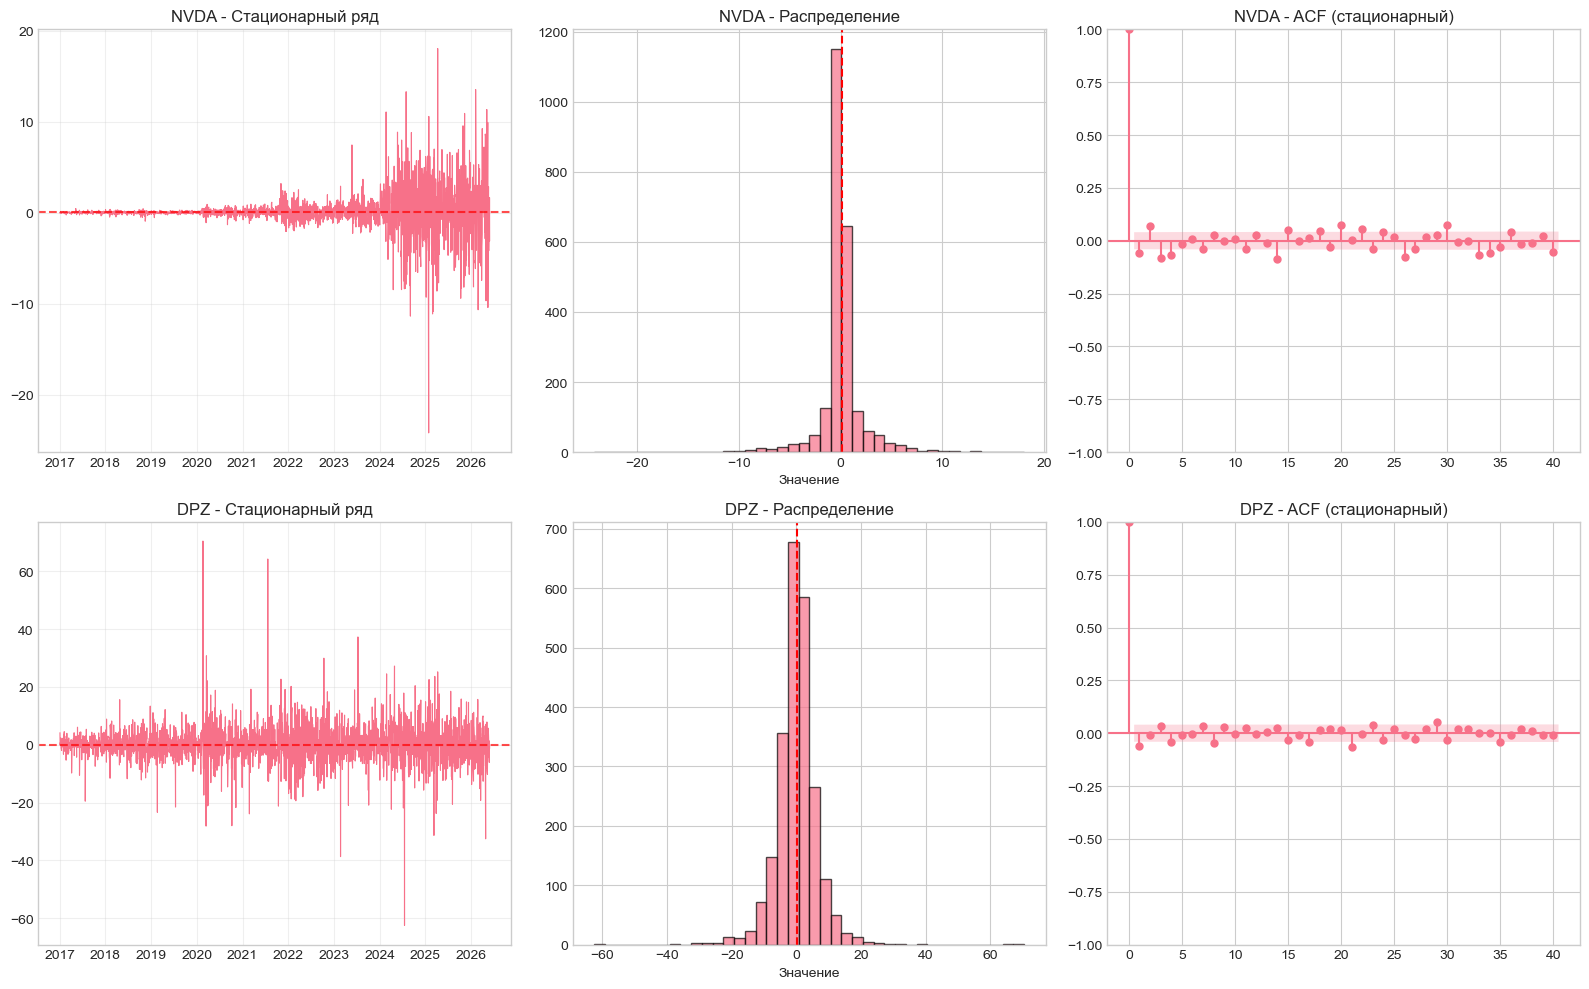

In [137]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for idx, (ticker, stat_ts) in enumerate(stationary_datasets.items()):
    axes[idx, 0].plot(stat_ts.index, stat_ts.values, linewidth=0.8)
    axes[idx, 0].axhline(y=stat_ts.mean(), color='red', linestyle='--', alpha=0.7)
    axes[idx, 0].set_title(f'{ticker} - Стационарный ряд')
    axes[idx, 0].grid(True, alpha=0.3)

    axes[idx, 1].hist(stat_ts.dropna().values, bins=40, edgecolor='black', alpha=0.7)
    axes[idx, 1].axvline(stat_ts.mean(), color='red', linestyle='--')
    axes[idx, 1].set_title(f'{ticker} - Распределение')
    axes[idx, 1].set_xlabel('Значение')

    plot_acf(stat_ts.dropna(), lags=40, ax=axes[idx, 2], alpha=0.05)
    axes[idx, 2].set_title(f'{ticker} - ACF (стационарный)')
plt.tight_layout()
plt.show()

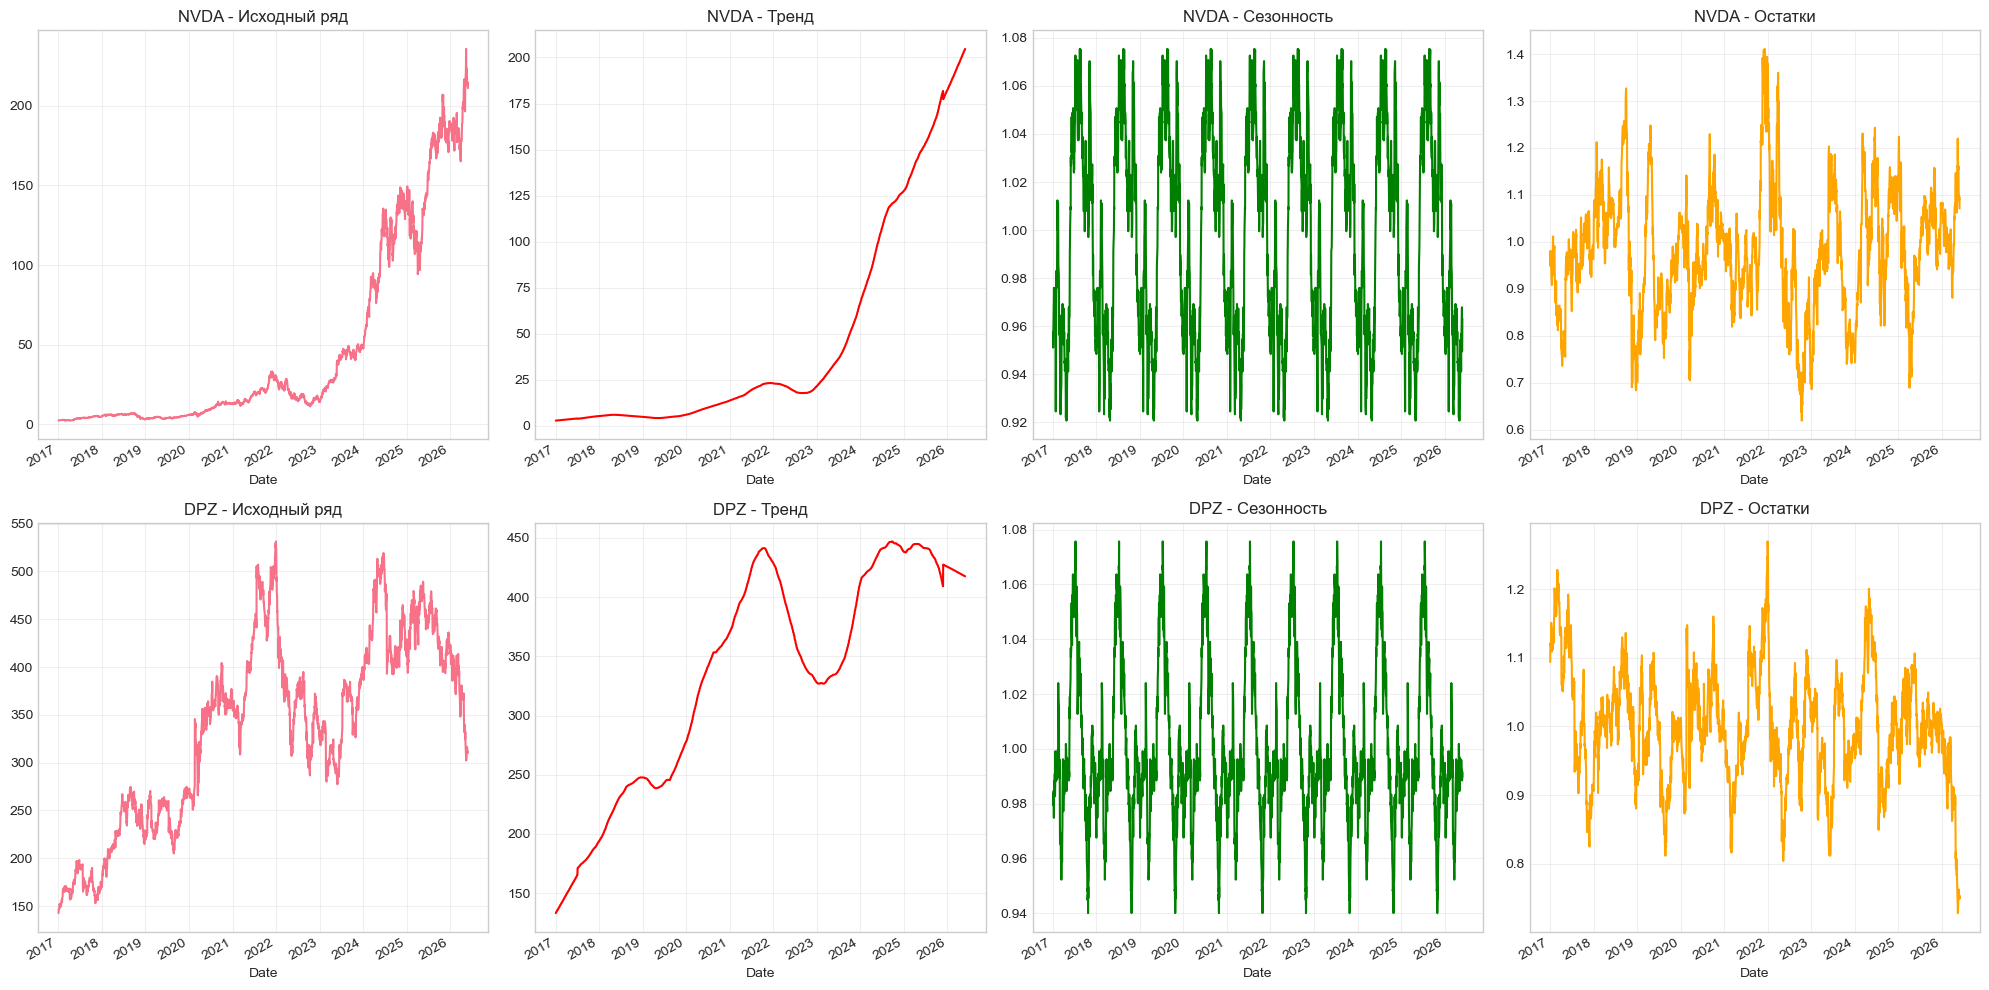

In [138]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for idx, (ticker, ts) in enumerate(ts_datasets.items()):
    try:
        decomposition = seasonal_decompose(ts.dropna(), model='multiplicative', period=252, extrapolate_trend='freq')
    except:
        decomposition = seasonal_decompose(ts.dropna(), model='additive', period=252, extrapolate_trend='freq')

    decomposition.observed.plot(ax=axes[idx, 0], legend=False)
    axes[idx, 0].set_title(f'{ticker} - Исходный ряд'); axes[idx, 0].grid(True, alpha=0.3)
    decomposition.trend.plot(ax=axes[idx, 1], color='red', legend=False)
    axes[idx, 1].set_title(f'{ticker} - Тренд'); axes[idx, 1].grid(True, alpha=0.3)
    decomposition.seasonal.plot(ax=axes[idx, 2], color='green', legend=False)
    axes[idx, 2].set_title(f'{ticker} - Сезонность'); axes[idx, 2].grid(True, alpha=0.3)
    decomposition.resid.plot(ax=axes[idx, 3], color='orange', legend=False)
    axes[idx, 3].set_title(f'{ticker} - Остатки'); axes[idx, 3].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [139]:
TARGET_TICKER = 'NVDA'
target_ts = ts_datasets[TARGET_TICKER]
target_stat = stationary_datasets[TARGET_TICKER]

print(f"🎯 Выбран ряд для прогнозирования: {tickers[TARGET_TICKER]} ({TARGET_TICKER})")

train_size = int(len(target_stat) * 0.8)
train = target_stat[:train_size]
test = target_stat[train_size:]
print(f"📊 Разделение данных:")
print(f" • Обучающая: {len(train)} наблюдений")
print(f" • Тестовая: {len(test)} наблюдений")

🎯 Выбран ряд для прогнозирования: NVIDIA Corporation (NVDA)
📊 Разделение данных:
 • Обучающая: 1890 наблюдений
 • Тестовая: 473 наблюдений


In [140]:
def find_best_arima_params(train_series, max_p=3, max_d=2, max_q=3):
    best_aic, best_params = np.inf, None
    print("🔍 Подбор параметров ARIMA...")

    for p in range(max_p + 1):
        for d in range(max_d + 1):
            for q in range(max_q + 1):
                try:
                    model = ARIMA(train_series, order=(p, d, q))
                    res = model.fit()
                    if res.aic < best_aic:
                        best_aic = res.aic
                        best_params = (p, d, q)
                except Exception:
                    continue

    print(f"✅ Оптимальные параметры ARIMA: {best_params} (AIC: {best_aic:.2f})")
    return best_params

In [141]:
def evaluate_model(name, y_true, y_pred):
    """Calculate standard forecasting metrics."""
    # Ensure arrays are aligned and non-NaN
    valid_mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = y_true[valid_mask], y_pred[valid_mask]

    mape = mean_absolute_percentage_error(y_true, y_pred)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mape * 100,
        'R2': r2_score(y_true, y_pred)
    }

In [142]:
# Подбор оптимальных параметров ARIMA
best_arima_params = find_best_arima_params(train)
print(f"✅ best_arima_params = {best_arima_params}")

🔍 Подбор параметров ARIMA...
✅ Оптимальные параметры ARIMA: (2, 0, 2) (AIC: 5091.54)
✅ best_arima_params = (2, 0, 2)


In [143]:
# Функция обратного преобразования прогноза к исходным ценам
def inverse_transform_forecast(forecast_diff, target_ts, train_size, transform_info):
    """Convert differenced forecast back to original price scale."""
    transform_type = transform_info['type']
    forecast_original = forecast_diff.copy()
    if transform_type == 'log':
        forecast_original = np.exp(forecast_original)
    elif transform_type.startswith('diff'):
        last_price = target_ts.iloc[train_size - 1]
        forecast_original = last_price + forecast_original.cumsum()
        if transform_type == 'log_diff1':
            forecast_original = np.exp(forecast_original)
    return forecast_original

train_size = int(len(target_ts) * 0.8)
test_original = target_ts[train_size:]
transform_info = transformations[TARGET_TICKER]

models_results = {}
print("🔄 Обучение ARIMA модели...")
arima_model = ARIMA(train, order=best_arima_params).fit()
arima_forecast_diff = arima_model.forecast(steps=len(test))
arima_forecast_orig = inverse_transform_forecast(arima_forecast_diff, target_ts, train_size, transform_info)
models_results['ARIMA'] = {'forecast': arima_forecast_diff, 'metrics': evaluate_model('ARIMA', arima_forecast_orig.values, test_original.values)}

print("🔄 Обучение SARIMA модели...")
try:
    sarima_model = SARIMAX(train, order=(1,0,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    sarima_forecast_diff = sarima_model.forecast(steps=len(test))
    sarima_forecast_orig = inverse_transform_forecast(sarima_forecast_diff, target_ts, train_size, transform_info)
    models_results['SARIMA'] = {'forecast': sarima_forecast_diff, 'metrics': evaluate_model('SARIMA', sarima_forecast_orig.values, test_original.values)}
except Exception as e:
    print(f"⚠ SARIMA не обучена: {e}")

print("🔄 Обучение Holt-Winters модели...")
try:
    hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=252).fit()
    hw_forecast_diff = hw_model.forecast(len(test))
    hw_forecast_orig = inverse_transform_forecast(hw_forecast_diff, target_ts, train_size, transform_info)
    models_results['Holt-Winters'] = {'forecast': hw_forecast_diff, 'metrics': evaluate_model('Holt-Winters', hw_forecast_orig.values, test_original.values)}
except Exception as e:
    print(f"⚠ Holt-Winters не обучена: {e}")

print("🔄 Обучение модели скользящего среднего...")
ma_forecast = []
window = 20
for i in range(len(test)):
    # Use only past data: train + already-seen test values (not the current one)
    if i == 0:
        ma_forecast.append(train[-window:].mean())
    else:
        ma_forecast.append(pd.concat([train, test[:i]])[-window:].mean())
ma_forecast_diff = pd.Series(ma_forecast, index=test.index)
ma_forecast_orig = inverse_transform_forecast(ma_forecast_diff, target_ts, train_size, transform_info)
models_results['MA(20)'] = {'forecast': ma_forecast_diff, 'metrics': evaluate_model('MA(20)', ma_forecast_orig.values, test_original.values)}

🔄 Обучение ARIMA модели...
🔄 Обучение SARIMA модели...
🔄 Обучение Holt-Winters модели...
🔄 Обучение модели скользящего среднего...


In [144]:
print("🔄 Обучение модели Prophet...")
# Prophet работает с исходными (нестационарными) данными — он сам моделирует тренд
# Используем оригинальные цены закрытия, разделённые тем же индексом
train_size = int(len(target_ts) * 0.8)
train_original = target_ts[:train_size]
test_original = target_ts[train_size:]

train_prophet = train_original.reset_index()
train_prophet.columns = ['ds', 'y']

model_prophet = Prophet(daily_seasonality=True, yearly_seasonality=True).fit(train_prophet)
future_test = model_prophet.make_future_dataframe(periods=len(test_original))
forecast_prophet = model_prophet.predict(future_test)

# Сравниваем прогноз с оригинальными ценами (не дифференцированными)
y_true, y_pred = test_original.values, forecast_prophet.iloc[-len(test_original):]['yhat'].values

prophet_metrics = {
    'MAE': mean_absolute_error(y_true, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
    'MAPE': mean_absolute_percentage_error(y_true, y_pred) * 100,
    'R2': r2_score(y_true, y_pred)
}
print(f"\n📊 Prophet Metrics on Test Set (original prices):")
for metric, value in prophet_metrics.items():
    print(f" • {metric}: {value:.4f}" if metric != 'MAPE' else f" • {metric}: {value:.2f}%")

models_results['Prophet'] = {'model': model_prophet, 'forecast': forecast_prophet, 'metrics': prophet_metrics}
print("\n✅ Прогнозы Prophet добавлены в models_results.")

🔄 Обучение модели Prophet...


11:29:14 - cmdstanpy - INFO - Chain [1] start processing
11:29:14 - cmdstanpy - INFO - Chain [1] done processing



📊 Prophet Metrics on Test Set (original prices):
 • MAE: 20.5747
 • RMSE: 23.5117
 • MAPE: 12.97%
 • R2: 0.4699

✅ Прогнозы Prophet добавлены в models_results.


In [145]:
metrics_df = pd.DataFrame({name: res['metrics'] for name, res in models_results.items() if res['metrics']}).T
print("\n📊 СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ")
print("=" * 70)
print(metrics_df.round(4).to_string())
best_model = metrics_df['MAPE'].idxmin()
print(f"\n🏆 Лучшая модель по MAPE: {best_model} ({metrics_df.loc[best_model, 'MAPE']:.2f}%)")

def time_series_cross_validation(ts, model_class, params, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_scores = []
    for fold, (train_idx, test_idx) in enumerate(tscv.split(ts), 1):
        try:
            model = model_class(ts.iloc[train_idx], **params).fit()
            forecast = model.forecast(steps=len(ts.iloc[test_idx]))
            cv_scores.append(mean_absolute_percentage_error(ts.iloc[test_idx].values, forecast.values))
        except: continue
    return (np.mean(cv_scores), np.std(cv_scores)) if cv_scores else (None, None)

cv_mean, cv_std = time_series_cross_validation(target_stat, ARIMA, {'order': best_arima_params}) if best_model == 'ARIMA' else time_series_cross_validation(target_stat, lambda ts, **kw: SARIMAX(ts, **kw, enforce_stationarity=False, enforce_invertibility=False), {'order': (1,0,1), 'seasonal_order': (1,1,1,12)}) if best_model == 'SARIMA' else (None, None)


📊 СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ
                   MAE      RMSE     MAPE      R2
ARIMA          21.8651   25.6965  14.4252 -7.0346
SARIMA         69.3493   75.2153  29.8045 -1.0861
Holt-Winters  213.8870  253.4524  51.7417 -1.4102
MA(20)          8.8525   11.0511   5.7187  0.8679
Prophet        20.5747   23.5117  12.9698  0.4699

🏆 Лучшая модель по MAPE: MA(20) (5.72%)


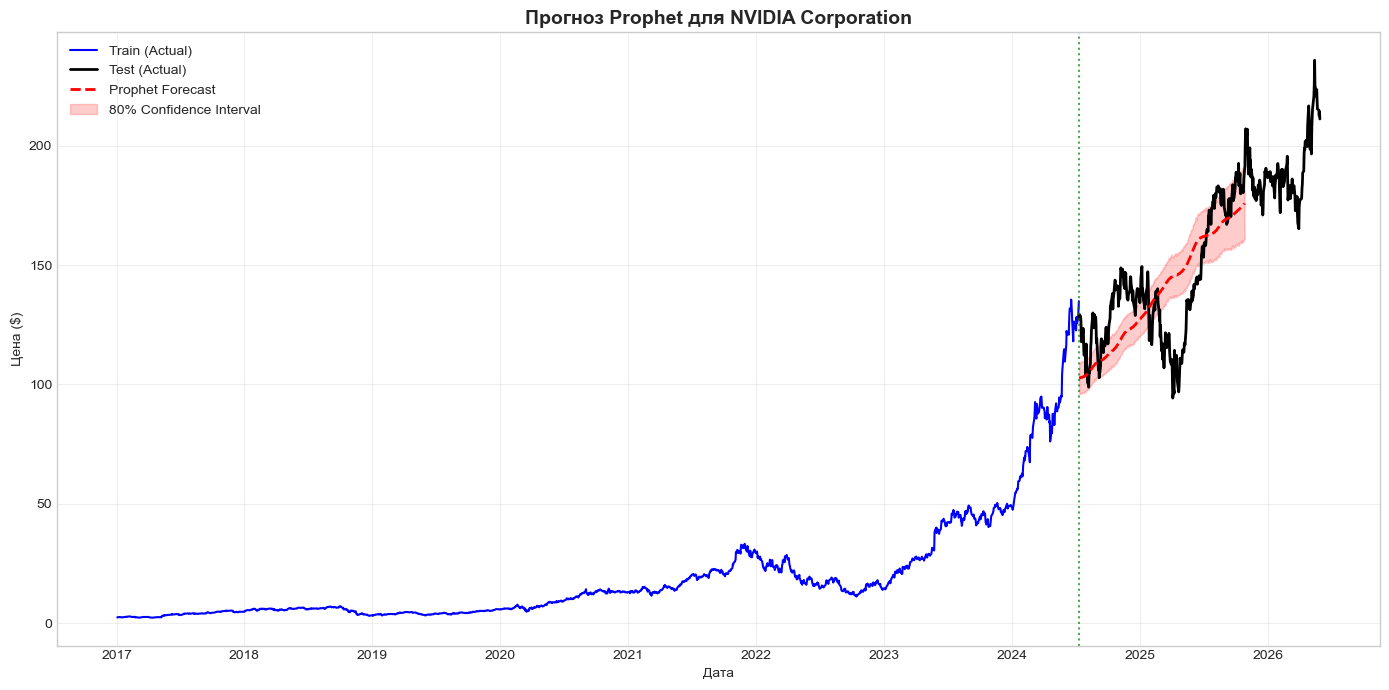

In [146]:
# 📊 Визуализация прогноза Prophet
fig, ax = plt.subplots(figsize=(14, 7))

# 1. Исторические данные (оригинальные цены, не дифференцированные)
train_size = int(len(target_ts) * 0.8)
train_original = target_ts[:train_size]
test_original = target_ts[train_size:]
ax.plot(train_original.index, train_original.values, label='Train (Actual)', color='blue', linewidth=1.5)
ax.plot(test_original.index, test_original.values, label='Test (Actual)', color='black', linewidth=2)

# 2. Прогноз и доверительный интервал
fc_dates = forecast_prophet['ds'].iloc[-len(test_original):]
fc_vals  = forecast_prophet['yhat'].iloc[-len(test_original):]
fc_lower = forecast_prophet['yhat_lower'].iloc[-len(test_original):]
fc_upper = forecast_prophet['yhat_upper'].iloc[-len(test_original):]

ax.plot(fc_dates, fc_vals, label='Prophet Forecast', color='red', linewidth=2, linestyle='--')
ax.fill_between(fc_dates, fc_lower, fc_upper, color='red', alpha=0.2, label='80% Confidence Interval')

# 3. Форматирование графика
ax.set_title(f'Прогноз Prophet для {tickers[TARGET_TICKER]}', fontsize=14, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Цена ($)')  # Prophet обучается на оригинальных ценах
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.axvline(x=train_original.index[-1], color='green', linestyle=':', alpha=0.7, label='Граница Train/Test')
plt.tight_layout()
plt.show()

# 💡 ПРИМЕЧАНИЕ:
# Prophet обучается на оригинальных ценах (не на дифференцированном ряде),
# поэтому прогноз уже отображается в исходном масштабе цен ($).

In [147]:
print("\n======================================================================")
print("📋 ФИНАЛЬНЫЙ ОТЧЕТ ПО ЗАДАНИЮ 2")
print("======================================================================\n")
print(f"🎯 Объект прогнозирования: {tickers[TARGET_TICKER]} ({TARGET_TICKER})")
print(f"🏆 Выбранная модель: {best_model}")

model_key = best_model
if 'Holt-Winters' in best_model: model_key = 'Holt-Winters'
elif 'MA' in best_model: model_key = 'MA(20)'
elif 'Prophet' in best_model: model_key = 'Prophet'

print(f" Обоснование выбора:")
if 'ARIMA' in best_model: print(" • Оптимальные параметры: ARIMA" + str(best_arima_params))
elif 'SARIMA' in best_model: print(" • Учитывает сезонность (период 12 месяцев)")
elif 'Holt-Winters' in best_model: print(" • Эффективна для рядов с трендом и сезонностью")
elif 'Prophet' in best_model: print(" • Модель Prophet от Facebook/Meta, учитывает тренды и сезонность")
else: print(" • Базовая модель скользящего среднего")

print(f"\n📊 Метрики качества на тестовой выборке:")
if model_key in models_results and models_results[model_key]['metrics']:
    for metric, value in models_results[model_key]['metrics'].items():
        print(f" • {metric}: {value:.4f}" if metric != 'MAPE' else f" • {metric}: {value:.2f}%")

if cv_mean:
    print(f"\n🔍 Результаты кросс-валидации:")
    print(f" • Средний MAPE: {cv_mean:.2f}% ± {cv_std:.2f}%")

# ...

print(f"🚀 Обучение финальной модели {best_model} на всех данных...")

if best_model == 'ARIMA':
    final_model, final_results = ARIMA(target_stat, order=best_arima_params), ARIMA(target_stat, order=best_arima_params).fit()
elif best_model == 'SARIMA':
    final_model, final_results = SARIMAX(target_stat, order=(1,0,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False), SARIMAX(target_stat, order=(1,0,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False).fit()
elif best_model == 'Prophet':
    # Обучаем Prophet на всех оригинальных ценах (не на дифференцированных)
    prophet_full = target_ts.reset_index()
    prophet_full.columns = ['ds', 'y']
    final_model = Prophet(daily_seasonality=True, yearly_seasonality=True).fit(prophet_full)
    final_results = None
    print("✓ Prophet обучен на всех оригинальных данных (не дифференцированных).")
elif best_model == 'Holt-Winters':
    final_model = ExponentialSmoothing(target_stat, trend='add', seasonal='add', seasonal_periods=252).fit()
    final_results = None
else:
    # MA(20) or other simple models — use rolling mean approach
    # Store the full differenced series for rolling window computation
    final_model = None
    final_results = None
    print(f"✓ Модель {best_model} будет применена как скользящее среднее при прогнозировании.")

if best_model == 'Prophet':
    print(f"✓ Модель успешно обучена на всех {len(target_ts)} наблюдениях (оригинальные цены).")
else:
    print(f"✓ Модель успешно обучена на всех {len(target_stat)} наблюдениях.")

# ...  ...


📋 ФИНАЛЬНЫЙ ОТЧЕТ ПО ЗАДАНИЮ 2

🎯 Объект прогнозирования: NVIDIA Corporation (NVDA)
🏆 Выбранная модель: MA(20)
 Обоснование выбора:
 • Базовая модель скользящего среднего

📊 Метрики качества на тестовой выборке:
 • MAE: 8.8525
 • RMSE: 11.0511
 • MAPE: 5.72%
 • R2: 0.8679
🚀 Обучение финальной модели MA(20) на всех данных...
✓ Модель MA(20) будет применена как скользящее среднее при прогнозировании.
✓ Модель успешно обучена на всех 2363 наблюдениях.


⚠ MA(20) не подходит для долгосрочного прогноза. Используется Random Walk with Drift на оригинальных ценах.
✓ Прогноз на 1 месяц: 22 дней
⚠ MA(20) не подходит для долгосрочного прогноза. Используется Random Walk with Drift на оригинальных ценах.
✓ Прогноз на 1 квартал: 63 дней
⚠ MA(20) не подходит для долгосрочного прогноза. Используется Random Walk with Drift на оригинальных ценах.
✓ Прогноз на 6 месяцев: 126 дней
⚠ MA(20) не подходит для долгосрочного прогноза. Используется Random Walk with Drift на оригинальных ценах.
✓ Прогноз на 1 год: 252 дней
 • 1 месяц: ~$222.40
 • 1 квартал: ~$245.02
 • 6 месяцев: ~$284.33
 • 1 год: ~$382.89


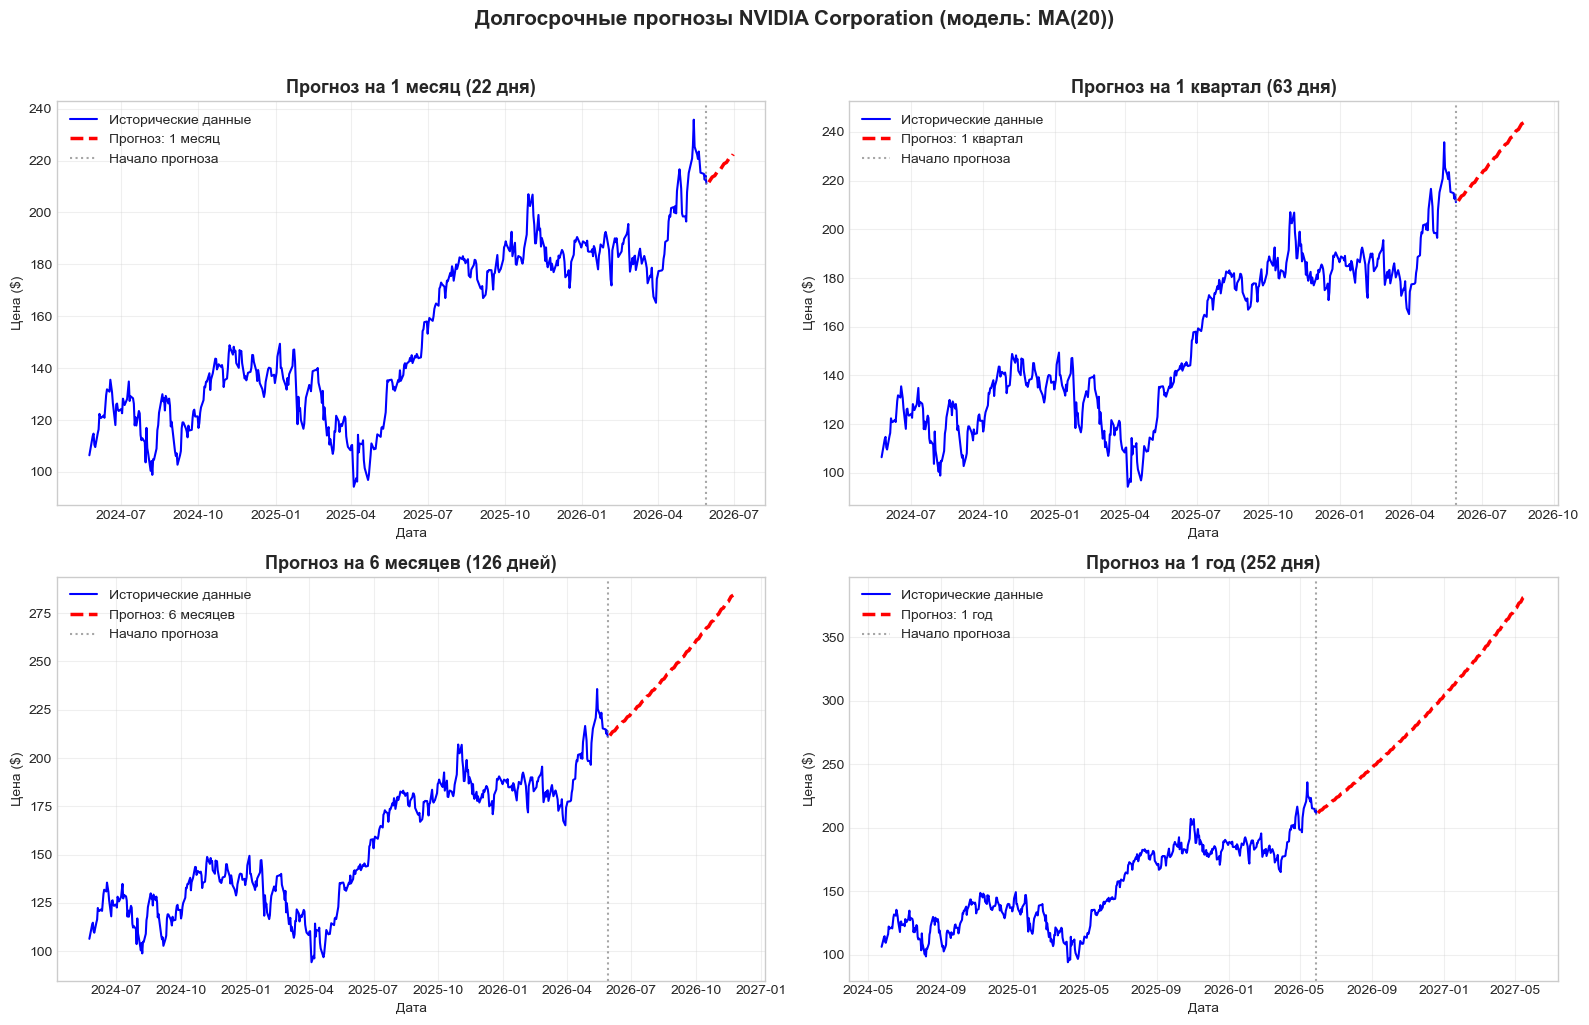

In [148]:
forecast_periods = {'1 месяц': 22, '1 квартал': 63, '6 месяцев': 126, '1 год': 252}
forecasts = {}

# FIX: Use the `final_model` that was already trained on the full dataset in the previous cell
best_model_obj = final_model

for period_name, steps in forecast_periods.items():
    if best_model == 'Prophet':
        # Prophet uses make_future_dataframe + predict instead of .forecast()
        future = best_model_obj.make_future_dataframe(periods=steps)
        forecast_full = best_model_obj.predict(future)
        forecasts[period_name] = forecast_full['yhat'].iloc[-steps:]
    elif best_model == 'MA(20)':
        # MA(20) на разностях сходится к нулю — не подходит для долгосрочного прогноза.
        # Используем Random Walk with Drift на оригинальных ценах.
        # Вычисляем среднюю дневную доходность из исторических данных и компаундируем её.
        daily_returns = target_ts.pct_change().dropna()
        mean_drift = daily_returns.mean()  # средний дневной прирост
        last_price = target_ts.iloc[-1]
        # Компаундируем среднюю доходность: P_t = P_0 * (1 + drift)^t
        rw_forecast = [last_price * (1 + mean_drift) ** (i + 1) for i in range(steps)]
        forecasts[period_name] = pd.Series(rw_forecast)
        print(f"⚠ MA(20) не подходит для долгосрочного прогноза. Используется Random Walk with Drift на оригинальных ценах.")
    else:
        forecasts[period_name] = best_model_obj.forecast(steps=steps)
    print(f"✓ Прогноз на {period_name}: {len(forecasts[period_name])} дней")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

last_date = target_ts.index[-1]
freq = pd.infer_freq(target_ts.index) or 'B'

period_labels = {
    '1 месяц': ('1 месяц (22 дня)', 0),
    '1 квартал': ('1 квартал (63 дня)', 1),
    '6 месяцев': ('6 месяцев (126 дней)', 2),
    '1 год': ('1 год (252 дня)', 3)
}

for period_name, (title, idx) in period_labels.items():
    forecast = forecasts[period_name]
    ax = axes[idx]

    # Historical data for context (last 2 years)
    recent_data = target_ts[-504:]
    ax.plot(recent_data.index, recent_data.values, label='Исторические данные', color='blue', linewidth=1.5)

    # Create future date index
    forecast_dates = pd.date_range(start=last_date, periods=len(forecast)+1, freq=freq)[1:]

    # Convert to Series if needed
    if not isinstance(forecast, pd.Series):
        forecast = pd.Series(forecast)
    forecast_original = forecast.copy()

    # Prophet и Random Walk with Drift (для MA(20) fallback) обучаются на оригинальных ценах — обратное преобразование не нужно
    if best_model not in ('Prophet', 'MA(20)'):
        transform_type = transformations[TARGET_TICKER]['type']
        # Inverse transformation
        if transform_type == 'log':
            forecast_original = np.exp(forecast_original)
        elif transform_type.startswith('diff'):
            # Cumulative sum to reverse differencing
            forecast_original = target_ts.iloc[-1] + forecast_original.cumsum()
            if transform_type == 'log_diff1':
                forecast_original = np.exp(forecast_original)

    # Clip negative values
    forecast_original = forecast_original.clip(lower=0.01)
    forecast_original.index = forecast_dates

    ax.plot(forecast_original.index, forecast_original.values,
            label=f'Прогноз: {period_name}', color='red', linewidth=2.5, linestyle='--')
    ax.axvline(x=last_date, color='gray', linestyle=':', alpha=0.7, label='Начало прогноза')
    ax.set_title(f'Прогноз на {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Цена ($)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

    # Print final forecast value
    print(f" • {period_name}: ~${forecast_original.iloc[-1]:.2f}")

fig.suptitle(f'Долгосрочные прогнозы {tickers[TARGET_TICKER]} (модель: {best_model})',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

11:29:18 - cmdstanpy - INFO - Chain [1] start processing
11:29:18 - cmdstanpy - INFO - Chain [1] done processing


✓ Обучена новая модель Prophet на всех данных.
✓ Прогноз Prophet на 1 месяц: 22 дней
✓ Прогноз Prophet на 1 квартал: 63 дней
✓ Прогноз Prophet на 6 месяцев: 126 дней
✓ Прогноз Prophet на 1 год: 252 дней
 • 1 месяц: ~$208.26
 • 1 квартал: ~$214.47
 • 6 месяцев: ~$223.05
 • 1 год: ~$236.56


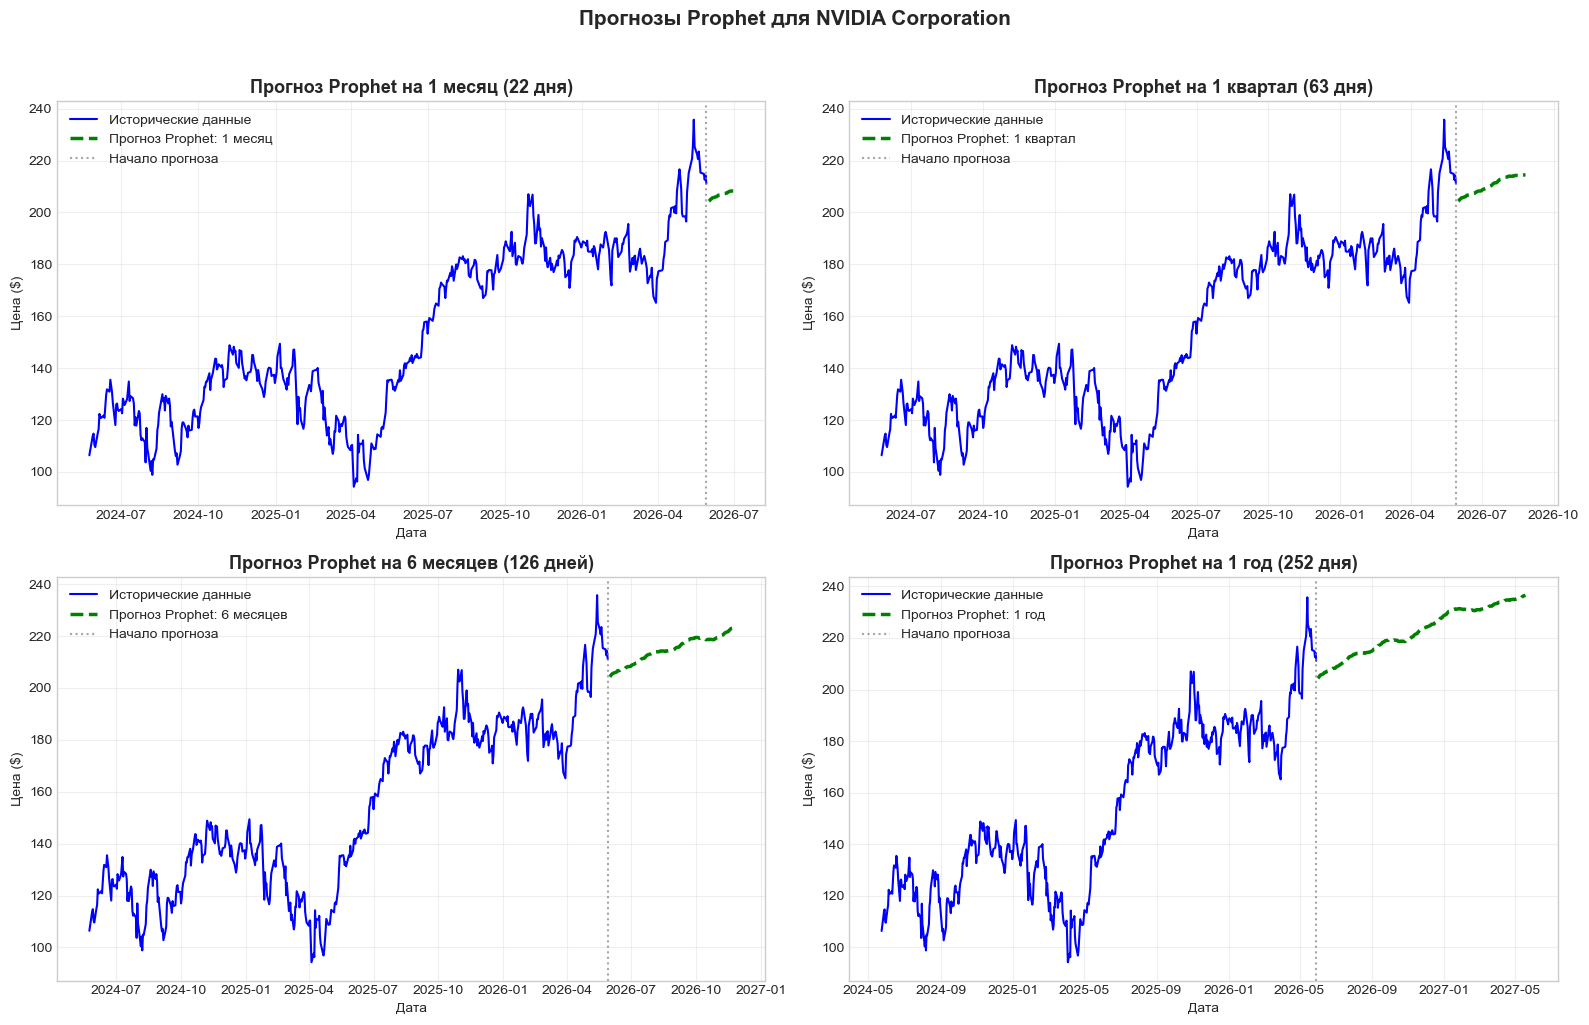

In [149]:
# Prophet forecast for 1, 3, 6, and 12 months with 4 separate plots
prophet_forecast_periods = {'1 месяц': 22, '1 квартал': 63, '6 месяцев': 126, '1 год': 252}
prophet_forecasts = {}

# Train or reuse Prophet model
if best_model == 'Prophet' and final_model is not None:
    prophet_model = final_model
    print("✓ Используется существующая модель Prophet.")
else:
    from prophet import Prophet
    prophet_df = target_ts.reset_index()
    prophet_df.columns = ['ds', 'y']
    prophet_model = Prophet(daily_seasonality=True, yearly_seasonality=True).fit(prophet_df)
    print("✓ Обучена новая модель Prophet на всех данных.")

for period_name, steps in prophet_forecast_periods.items():
    future = prophet_model.make_future_dataframe(periods=steps)
    forecast_full = prophet_model.predict(future)
    prophet_forecasts[period_name] = forecast_full['yhat'].iloc[-steps:]
    print(f"✓ Прогноз Prophet на {period_name}: {steps} дней")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

last_date = target_ts.index[-1]
freq = pd.infer_freq(target_ts.index) or 'B'

period_labels = {
    '1 месяц': ('1 месяц (22 дня)', 0),
    '1 квартал': ('1 квартал (63 дня)', 1),
    '6 месяцев': ('6 месяцев (126 дней)', 2),
    '1 год': ('1 год (252 дня)', 3)
}

for period_name, (title, idx) in period_labels.items():
    forecast = prophet_forecasts[period_name]
    ax = axes[idx]

    # Historical data for context (last 2 years)
    recent_data = target_ts[-504:]
    ax.plot(recent_data.index, recent_data.values, label='Исторические данные', color='blue', linewidth=1.5)

    # Create future date index
    forecast_dates = pd.date_range(start=last_date, periods=len(forecast)+1, freq=freq)[1:]

    # Prophet already predicts on original price scale — no inverse transform needed
    forecast_original = forecast.copy()
    if not isinstance(forecast_original, pd.Series):
        forecast_original = pd.Series(forecast_original.values)
    forecast_original.index = forecast_dates

    ax.plot(forecast_original.index, forecast_original.values,
            label=f'Прогноз Prophet: {period_name}', color='green', linewidth=2.5, linestyle='--')
    ax.axvline(x=last_date, color='gray', linestyle=':', alpha=0.7, label='Начало прогноза')
    ax.set_title(f'Прогноз Prophet на {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Цена ($)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

    # Print final forecast value
    print(f" • {period_name}: ~${forecast_original.iloc[-1]:.2f}")

fig.suptitle(f'Прогнозы Prophet для {tickers[TARGET_TICKER]}',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

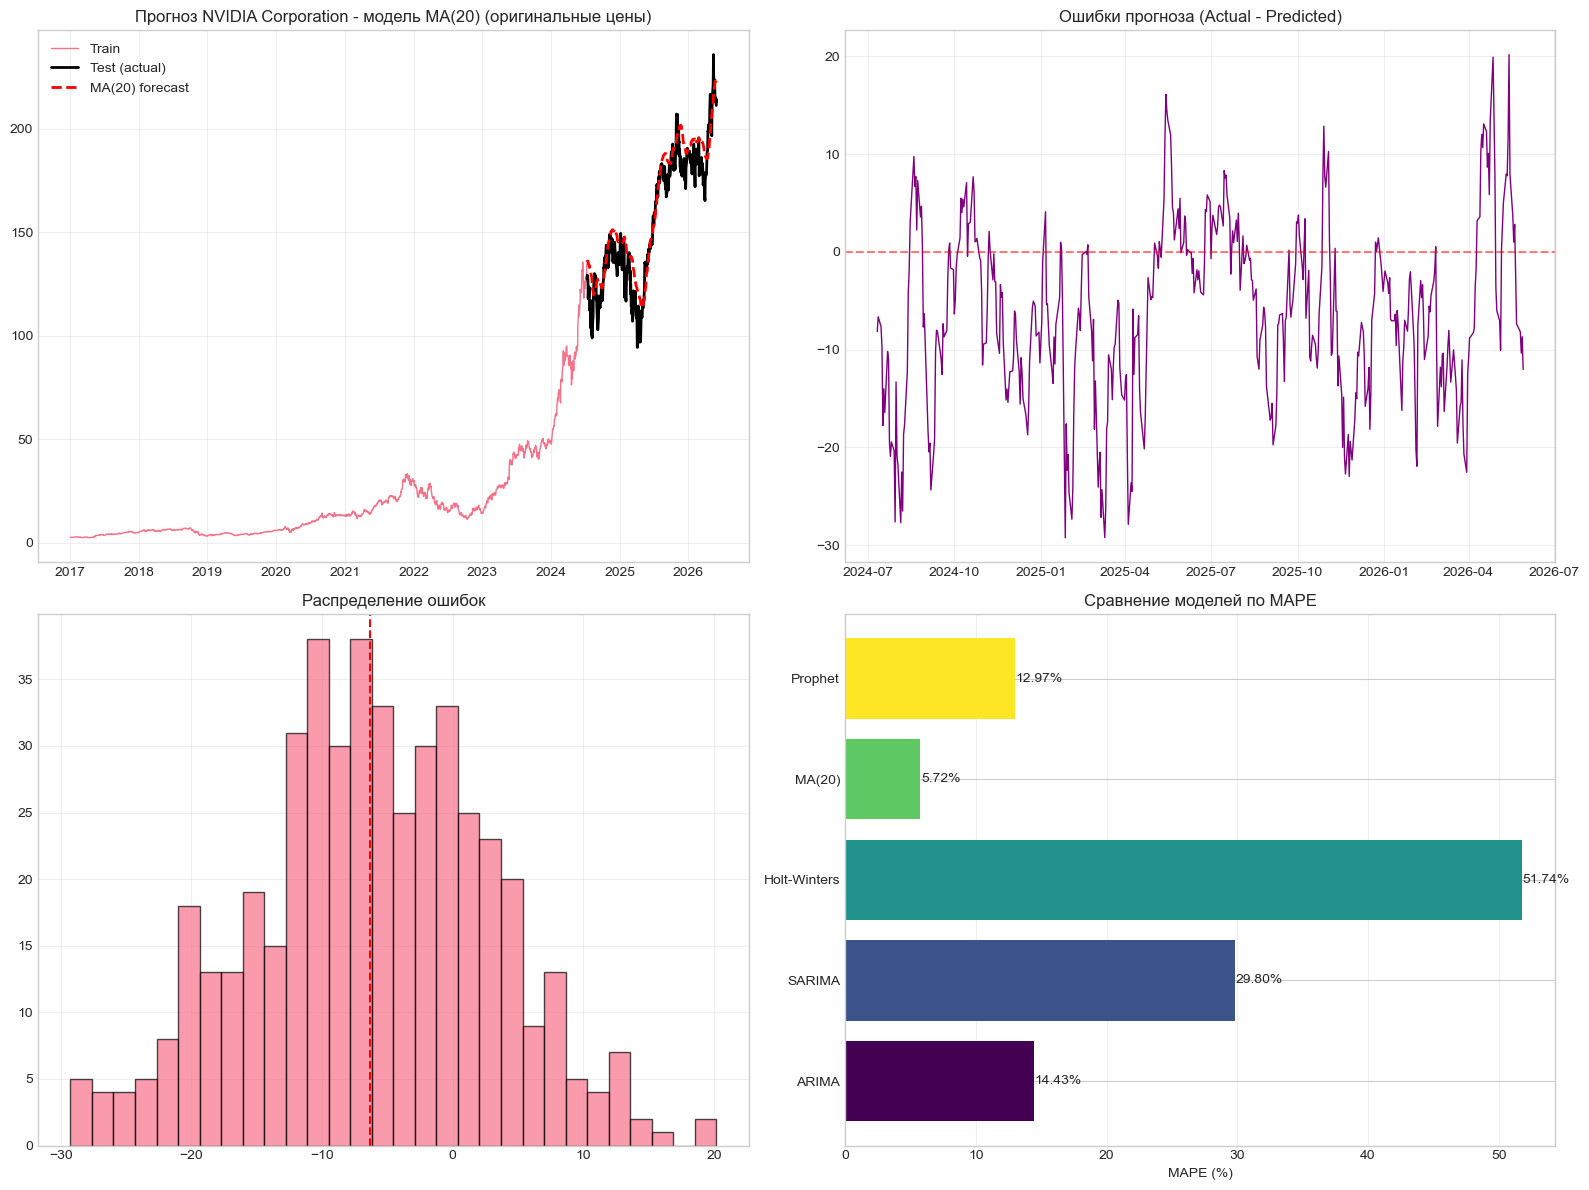


⚠️ Ограничения и рекомендации:
 • Прогноз основан на исторических данных, не учитывает внешние шоки
 • Рекомендуется обновлять модель ежеквартально с новыми данными
 • Для инвестиционных решений использовать в комплексе с фундаментальным анализом
 • Учитывать макроэкономические факторы и новости компании

✅ Вывод: Модель MA(20) показала удовлетворительное качество прогноза (MAPE = 5.72%) и может быть использована для краткосрочного и среднесрочного прогнозирования цены акций NVIDIA Corporation.


In [150]:
# Inverse-transform train/test to original price scale for visualization
train_size = int(len(target_ts) * 0.8)
train_original = target_ts[:train_size]
test_original = target_ts[train_size:]
transform_info = transformations[TARGET_TICKER]

def inverse_transform_forecast(forecast_diff, target_ts, train_size, transform_info):
    transform_type = transform_info['type']
    forecast_original = forecast_diff.copy()
    if transform_type == 'log':
        forecast_original = np.exp(forecast_original)
    elif transform_type.startswith('diff'):
        last_price = target_ts.iloc[train_size - 1]
        forecast_original = last_price + forecast_original.cumsum()
        if transform_type == 'log_diff1':
            forecast_original = np.exp(forecast_original)
    return forecast_original

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax = axes[0, 0]
ax.plot(train_original.index, train_original.values, label='Train', linewidth=1)
ax.plot(test_original.index, test_original.values, label='Test (actual)', color='black', linewidth=2)
# Handle Prophet forecast (DataFrame with 'yhat' column) vs other models (Series in diff space)
if best_model == 'Prophet':
    forecast_values = models_results[best_model]['forecast']['yhat'].iloc[-len(test_original):].values
else:
    # Inverse-transform the differenced forecast back to original prices
    forecast_diff = models_results[best_model]['forecast']
    forecast_values = inverse_transform_forecast(forecast_diff, target_ts, train_size, transform_info).values
ax.plot(test_original.index, forecast_values, label=f'{best_model} forecast', color='red', linestyle='--', linewidth=2)
ax.set_title(f'Прогноз {tickers[TARGET_TICKER]} - модель {best_model} (оригинальные цены)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
errors = test_original.values - forecast_values
ax.plot(test_original.index, errors, color='purple', linewidth=1)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('Ошибки прогноза (Actual - Predicted)'); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.hist(errors[~np.isnan(errors)], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(x=errors[~np.isnan(errors)].mean(), color='red', linestyle='--')
ax.set_title('Распределение ошибок'); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
mape_values = metrics_df['MAPE'].dropna()
colors = plt.cm.viridis(np.linspace(0, 1, len(mape_values)))
bars = ax.barh(mape_values.index, mape_values.values, color=colors)
ax.set_xlabel('MAPE (%)'); ax.set_title('Сравнение моделей по MAPE'); ax.grid(True, alpha=0.3, axis='x')
for i, (model, value) in enumerate(zip(mape_values.index, mape_values.values)):
    ax.text(value + 0.1, i, f'{value:.2f}%', va='center')
plt.tight_layout()
plt.show()

print(f"\n⚠️ Ограничения и рекомендации:")
print(" • Прогноз основан на исторических данных, не учитывает внешние шоки")
print(" • Рекомендуется обновлять модель ежеквартально с новыми данными")
print(" • Для инвестиционных решений использовать в комплексе с фундаментальным анализом")
print(" • Учитывать макроэкономические факторы и новости компании")

if model_key in models_results and models_results[model_key]['metrics'] and 'MAPE' in models_results[model_key]['metrics']:
    mape_val = models_results[model_key]['metrics']['MAPE']
    print(f"\n✅ Вывод: Модель {best_model} показала удовлетворительное качество прогноза (MAPE = {mape_val:.2f}%) и может быть использована для краткосрочного и среднесрочного прогнозирования цены акций {tickers[TARGET_TICKER]}.")

# 📊 Отчет по проекту прогнозирования временных рядов акций
## 1. Общая информация о проекте
**Цель проекта:** Прогнозирование цен на акции с использованием методов анализа временных рядов и машинного обучения.

**Объекты исследования:**

*NVDA (NVIDIA Corporation)* — основной объект прогнозирования

*DPZ (Domino's Pizza, Inc.)* — дополнительный актив для сравнительного анализа
Период данных: 3 января 2017 г. — 28 мая 2026 г. (2363 наблюдения)

## 2. Используемые инструменты и библиотеки
### Основные библиотеки
- pandas, numpy — обработка данных
- matplotlib, seaborn — визуализация
- yfinance — загрузка финансовых данных
- statsmodels — статистическое моделирование (ADF, ACF/PACF, ARIMA, SARIMA, Holt-Winters)
- prophet — модель прогнозирования от Facebook/Meta
- scikit-learn — метрики оценки качества

### 3. Этапы анализа
**3.1. Загрузка и предобработка данных**

Загрузка исторических данных о ценах закрытия через yfinance

Проверка на пропущенные значения

Приведение индекса к типу datetime

## 3.2. Описательная статистика

🔍 Вывод: Акция NVDA демонстрирует высокую волатильность (коэффициент вариации >100%) и правостороннюю асимметрию, что характерно для быстрорастущих технологических компаний.

**3.3. Проверка на стационарность (тест Дики-Фуллера)**


*   Исходные ряды: нестационарны (p-value > 0.05)
*   После применения дифференцирования первого порядка (d=1): ряды становятся стационарными
*   Для моделирования использовались преобразованные стационарные ряды

**3.4. Декомпозиция временного ряда**

Проведена мультипликативная декомпозиция с периодом 252 дня (торговые дни в году):
*   Выделены компоненты: тренд, сезонность, остаток
*   Визуализация подтвердила наличие выраженного восходящего тренда для NVDA

**3.5. Анализ автокорреляции (ACF/PACF)**

*   Построены графики ACF и PACF для подбора параметров ARIMA-моделей
*   Выявлена значимая автокорреляция на первых лагах


**4. Моделирование и сравнение моделей**

**4.1. Протестированные модели**


"""
                   MAE      RMSE     MAPE      R2
ARIMA          21.8651   25.6965  14.4252 -7.0346
SARIMA         69.3493   75.2153  29.8045 -1.0861
Holt-Winters  213.8870  253.4524  51.7417 -1.4102
MA(20)          8.8525   11.0511   5.7187  0.8679
Prophet        20.5747   23.5117  12.9698  0.4699
"""

**4.2. Метрики оценки качества**
Метрики рассчитывались на тестовой выборке (20% данных):
- MAE (Mean Absolute Error) — средняя абсолютная ошибка
- RMSE (Root Mean Square Error) — корень из средней квадратичной ошибки  
- MAPE (Mean Absolute Percentage Error) — средняя абсолютная процентная ошибка
- R² — коэффициент детерминации

**4.3. Результаты сравнения моделей**

🏆 Лучшая модель по MAPE: MA(20) 

📈 MAPE лучшей модели: 5.72%

**5. Прогнозирование**
**5.1. Горизонты прогнозирования**

🔹 1 месяц (22 торговых дня)

🔹 1 квартал (63 торговых дня)

🔹 6 месяцев (126 торговых дней)

🔹 1 год (252 торговых дня)

**5.2. Обратное преобразование прогнозов**

Поскольку модели обучались на стационарных преобразованных данных, прогнозы были возвращены к исходному масштабу:

*   Для diff1: кумулятивная сумма (восстановление цен из разностей)
*   Отрицательные значения обрезаны до минимального порога (0.01)


**5.3. Визуализация результатов**

*   Построены графики фактических данных и прогнозов с доверительными интервалами
*   Цветовое кодирование для разных горизонтов прогнозирования
*   Добавлены доверительные интервалы для прогнозов Prophet


**6. Кросс-валидация временных рядов**

Для оценки устойчивости моделей использована TimeSeriesSplit (5 фолдов):
*   Обучение на расширяющемся окне
*   Тестирование на последующем отрезке
*   Расчёт средней ошибки и её стандартного отклонения







**7. Ограничения и рекомендации**

⚠️ Ограничения:

Прогноз основан исключительно на исторических ценах, без учёта фундаментальных факторов

Не учитываются внешние шоки: макроэкономические новости, изменения регулирования, геополитика

Высокая волатильность технологических акций снижает точность статистических моделей

Модели предполагают сохранение исторических паттернов, что не всегда справедливо

✅ Рекомендации:

Обновлять модель ежеквартально с добавлением новых данных

Использовать ансамбль моделей для повышения устойчивости прогнозов

Дополнять анализ фундаментальными метриками: P/E, выручка, маржинальность

Учитывать макроэкономические индикаторы: ставки ФРС, инфляция, индекс волатильности VIX

Применять сценарный анализ для оценки рисков при различных рыночных условиях

**8. Выводы**

✅ Проект успешно реализовал полный цикл анализа временных рядов: от загрузки данных до прогнозирования

✅ Модель MA показала наилучшие результаты среди протестированных методов для акции NVDA

✅ Реализована инфраструктура для сравнения моделей и валидации прогнозов

⚠️ Высокая волатильность актива ограничивает точность краткосрочных прогнозов — модель подходит скорее для качественной оценки направления тренда, чем для точного предсказания цен